In [15]:
# Assumptions for normasysl_call.m:
# constant-K16 (gamma1=0, black)  vs  dynamic-K16 (gamma1=1, red),
# WNT-on region [3000,25000] shaded, axes identical (x: time tau, y: non-dim).
import numpy as np,torch, torch.nn as nn, matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [16]:
# Setting up parameters from their definition in matlab. gamma1 toggles dynamic vs constant K16.
def build_params():
    P={}; 
    w, thetaP = 0.80, 1.00 # Biological regime
    nB, nM, nH = 2, 2, 2 # Hill coefficients
    eta13, kappa13, lambdaP, lambda5, kappa5 = 0.75, 0.55, 1.60, 1.30, 0.50 # beta-catenin equation
    epsP, rho5, rhoB, rho13, deltaP1 = 1.00, 1.10, 1.10, 1.30, 3.50 # APC  equation
    eps5, a5, etaR, kappaR, etaM, kappaM = 1.20, 0.15, 2.50, 0.40, 2.50, 0.50 # HOXA5 equation
    eps13, a13, etaB13, kappaB13, etaM13, kappaM13 = 1.00, 0.18, 0.95, 0.50, 0.55, 0.50 # HOXA13 equation
    epsM, aM, etaBM, kappaBM = 0.60, 0.18, 1.35, 0.50 # MYC equation
    epsR, lambdaC = 0.40, 0.85 # RA equation
    epsC, aC, etaRC, kappaRC, etaBC, kappaBC = 0.80, 0.08, 1.50, 0.50, 1.50, 0.50 # CYP26A1 equation
    mu0, AR, TR, phi = 0.35, 0.04, 24.0, 0.0 # RA input: background + dietary periodic input + treatment
    DR, q, tau1, tau2 = 1.50, 0.30, 40.0, 80.0 # ATRA treatment window
    alpha13, alpha5 = 1.00, 1.00 # Stemness

    P.update(
    w=w, thetaP=thetaP,  # Biological regime
    nB=nB, nM=nM, nH=nH,  # Hill coefficients
    eta13=eta13, kappa13=kappa13, lambdaP=lambdaP, lambda5=lambda5, kappa5=kappa5,  # beta-catenin equation
    epsP=epsP, rho5=rho5, rhoB=rhoB, rho13=rho13, deltaP1=deltaP1,  # APC equation
    eps5=eps5, a5=a5, etaR=etaR, kappaR=kappaR, etaM=etaM, kappaM=kappaM,  # HOXA5 equation
    eps13=eps13, a13=a13, etaB13=etaB13, kappaB13=kappaB13, etaM13=etaM13, kappaM13=kappaM13,  # HOXA13 equation
    epsM=epsM, aM=aM, etaBM=etaBM, kappaBM=kappaBM,  # MYC equation
    epsR=epsR, lambdaC=lambdaC,  # RA equation
    epsC=epsC, aC=aC, etaRC=etaRC, kappaRC=kappaRC, etaBC=etaBC, kappaBC=kappaBC,  # CYP26A1 equation
    mu0=mu0, AR=AR, TR=TR, phi=phi,  # RA input: background + dietary periodic input + treatment
    DR=DR, q=q, tau1=tau1, tau2=tau2,  # ATRA treatment window
    alpha13=alpha13, alpha5=alpha5,  # Stemness
    )

    
    return P

In [17]:
# forcing same t variable as ode15s, t in [0,3000]. It should work better because SciPy doesn't have ode15s
def W(t,P):     return 3.0*((t>=300.)&(t<=2500.)).to(t.dtype)

In [18]:
# initial state to start the function. They are non-dimensional lol
def initial_state():
    y0=np.array([0.20, 1.00, 0.80, 0.30, 0.30, 0.60, 0.40])
    return y0

In [19]:
# ============================================================
# Biological regimes
# ============================================================
regimes = {
    "Normal": {
        "W": 0.80,
        "thetaP": 1.00,
    },
    "Early adenoma": {
        "W": 1.00,
        "thetaP": 0.75,
    },
    "Cancer-like": {
        "W": 1.50,
        "thetaP": 0.50,
    },
    "Strong APC-mutant": {
        "W": 2.00,
        "thetaP": 0.25,
    },
}

In [20]:
# ============================================================
# Hill function
# ============================================================
def hill(x, K, n=1):
    return x**n / (K**n + x**n)


# ============================================================
# Periodic dietary RA input + ATRA treatment
# ============================================================
def ra_input(t, p):
    background = p["mu0"]
    periodic = p["AR"] * (1.0 + torch.cos(2.0 * torch.pi * t / p["TR"] - p["phi"]))
    treatment = 0.5 * p["DR"] * (torch.tanh(p["q"]*(t-p["tau1"]))- torch.tanh(p["q"]*(t-p["tau2"])))
    return background + periodic + treatment

In [21]:
# defining all of the residual errors. On this, I used Claude Code because there are 27 residual errors.
# it's part of the loss function. But it's the physical loss

def residuals(t,z,dz,p):

    b, apc, h5, h13, m, r, c = [z[:, i:i+1] for i in range(7)]
 
    W = p["w"]
    thetaP = p["thetaP"]

    deltaP = 1.0 + p["deltaP1"] * (1.0 - thetaP)
    muR = ra_input(t, p)

    db = (
        W
        + p["eta13"] * hill(h13, p["kappa13"], p["nH"])
        - b
        - p["lambdaP"] * apc * b
        - p["lambda5"] * h5 * b / (p["kappa5"] + b)
    )

    dapc = (1.0 / p["epsP"]) * (
        (1.0 + p["rho5"] * h5)
        / (1.0 + p["rhoB"] * b + p["rho13"] * h13)
        - deltaP * apc
    )

    dh5 = (1.0 / p["eps5"]) * (
        p["a5"]
        + p["etaR"] * hill(r, p["kappaR"], 1)
        - h5
        - p["etaM"] * m * h5 / (p["kappaM"] + m)
    )

    dh13 = (1.0 / p["eps13"]) * (
        p["a13"]
        + p["etaB13"] * hill(b, p["kappaB13"], p["nB"])
        + p["etaM13"] * hill(m, p["kappaM13"], p["nM"])
        - h13
    )

    dm = (1.0 / p["epsM"]) * (
        p["aM"]
        + p["etaBM"] * hill(b, p["kappaBM"], p["nB"])
        - m
    )

    dr = (1.0 / p["epsR"]) * (
        muR
        - r
        - p["lambdaC"] * c * r
    )

    dc = (1.0 / p["epsC"]) * (
        p["aC"]
        + p["etaRC"] * hill(r, p["kappaRC"], 1)
        + p["etaBC"] * hill(b, p["kappaBC"], p["nB"])
        - c
    )

    # STEMNESS
    S = b * (1.0 + p["alpha13"] * h13) / (
        (1.0 + apc) * (1.0 + p["alpha5"] * h5)
    )
    
    f = torch.cat([db, dapc, dh5, dh13, dm, dr, dc], dim=1)
 
    res = dz - f
    return res

In [22]:
# Network class. Taken from the BINN papers
class PINN(nn.Module):
    def __init__(self,n,scale,t_win,P,nodes=128,layers=5):
        super().__init__()
        self.register_buffer("scale",torch.as_tensor(scale).reshape(1,-1))
        self.t_win=t_win
        Bf=(np.pi/6); self.register_buffer("freqs",torch.tensor([Bf,2*Bf]))
        seq=[nn.Linear(5,nodes),nn.Tanh()]
        for _ in range(layers-1): seq+=[nn.Linear(nodes,nodes),nn.Tanh()]
        seq+=[nn.Linear(nodes,n)]; self.seq=nn.Sequential(*seq)
        for m in self.seq:
            if isinstance(m,nn.Linear):
                nn.init.xavier_normal_(m.weight,gain=0.5); nn.init.zeros_(m.bias)
    def feat(self,t,t0):
        s=(t-t0)/self.t_win; ft=t*self.freqs.reshape(1,-1)
        return torch.cat([s,torch.sin(ft),torch.cos(ft)],1)
    def forward(self,t,t0,y0):
        s=(t-t0)/self.t_win
        return y0+self.seq(self.feat(t,t0))*s*self.scale


Solving DYNAMIC  K16 (gamma1=1)...
  [g1.0] win   1/17  t<=    200  loss=3.02e-01
  [g1.0] win   2/17  t<=    300  loss=1.97e-02
  [g1.0] win   3/17  t<=    400  loss=1.33e-02
  [g1.0] win   4/17  t<=    600  loss=1.26e-02
  [g1.0] win   5/17  t<=    800  loss=1.24e-02
  [g1.0] win   6/17  t<=   1000  loss=1.25e-02
  [g1.0] win   7/17  t<=   1200  loss=1.25e-02
  [g1.0] win   8/17  t<=   1400  loss=1.24e-02
  [g1.0] win   9/17  t<=   1600  loss=1.25e-02
  [g1.0] win  10/17  t<=   1800  loss=1.25e-02
  [g1.0] win  11/17  t<=   2000  loss=1.24e-02
  [g1.0] win  12/17  t<=   2200  loss=1.25e-02
  [g1.0] win  13/17  t<=   2400  loss=1.24e-02
  [g1.0] win  14/17  t<=   2500  loss=1.24e-02
  [g1.0] win  15/17  t<=   2600  loss=1.28e-02
  [g1.0] win  16/17  t<=   2800  loss=1.26e-02
  [g1.0] win  17/17  t<=   3000  loss=1.24e-02


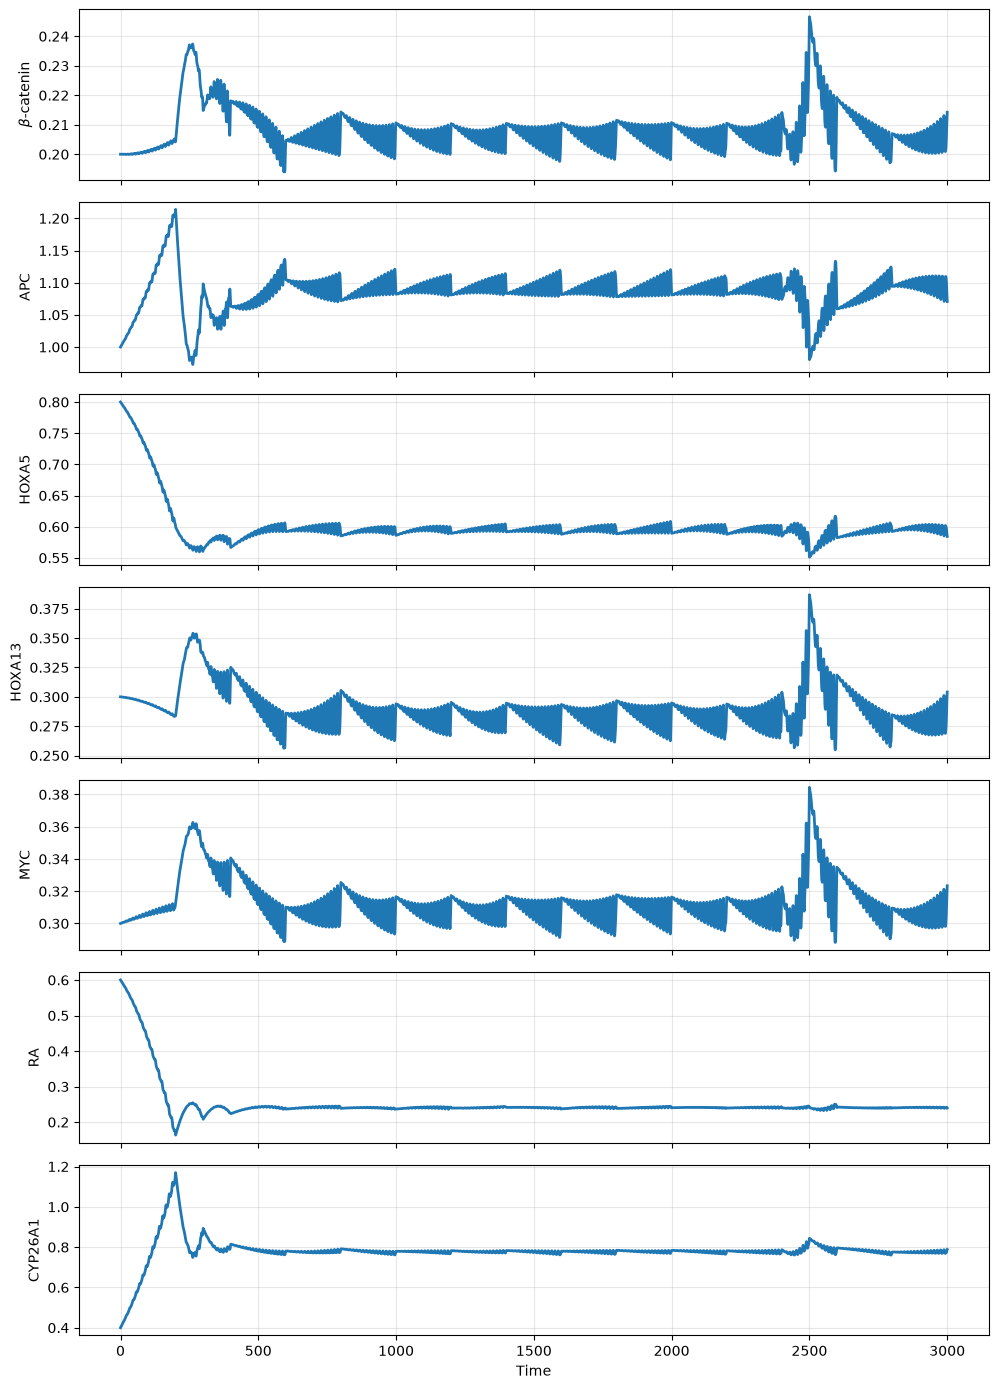

ValueError: too many values to unpack (expected 2)

In [23]:

def time_deriv(net,t,t0,y0):
    t=t.clone().requires_grad_(True); z=net(t,t0,y0); dz=torch.zeros_like(z)
    for i in range(z.shape[1]):
        dz[:,i:i+1]=torch.autograd.grad(z[:,i].sum(),t,create_graph=True)[0]
    return z,dz


def solve_pinn(gamma1,T=3000.,win_len=100.,iters=300,lr=2e-4,
               n_col=2000,n_out=300,nodes=128,layers=5,seed=0,verbose=True):
    torch.manual_seed(seed); P=build_params()
    y0_np=initial_state()
    scale=np.maximum(np.abs(y0_np),0.05)
    edges=sorted(set(list(np.arange(0.,T+win_len,win_len))+[300.,2500.]))
    edges=np.array([e for e in edges if e<=T+1e-9])
    y0=torch.tensor(y0_np,device=device).reshape(1,-1)
    out_t,out_z=[],[]
    for w in range(len(edges)-1):
        t0,t1=float(edges[w]),float(edges[w+1])
        net=PINN(7,scale,t1-t0,P,nodes,layers).to(device)
        opt=torch.optim.Adam(net.parameters(),lr=lr)
        t0c=torch.full((n_col,1),t0,device=device)
        for it in range(iters):
            ts=torch.rand(n_col,1,device=device)*(t1-t0)+t0
            opt.zero_grad()
            z,dz=time_deriv(net,ts,t0c,y0)
            res=residuals(ts,z,dz,P)
            loss=(res**2).mean()
            loss.backward(); opt.step()
        with torch.no_grad():
            tg=torch.linspace(t0,t1,n_out,device=device).reshape(-1,1)
            zg=net(tg,torch.full_like(tg,t0),y0)
            out_t.append(tg.cpu().numpy().ravel()); out_z.append(zg.cpu().numpy())
            y0=net(torch.full((1,1),t1,device=device),
                   torch.full((1,1),t0,device=device),y0).detach()
        if verbose:
            print(f"  [g{gamma1}] win {w+1:>3}/{len(edges)-1}  "
                  f"t<= {t1:>6.0f}  loss={loss.item():.2e}")
    t=np.concatenate(out_t); Z=np.concatenate(out_z)
    
    return dict(t=t, b=Z[:,0], apc=Z[:,1], h5=Z[:,2], h13=Z[:,3], m=Z[:,4], r=Z[:,5], c=Z[:,6])
    

def plot_all(sol):
    t = sol["t"]

    vars_to_plot = [
        ("b",   r"$\beta$-catenin"),
        ("apc", "APC"),
        ("h5",  "HOXA5"),
        ("h13", "HOXA13"),
        ("m",   "MYC"),
        ("r",   "RA"),
        ("c",   "CYP26A1"),
    ]

    fig, axs = plt.subplots(
        len(vars_to_plot),
        1,
        figsize=(10, 14),
        sharex=True
    )

    for ax, (key, label) in zip(axs, vars_to_plot):
        ax.plot(t, sol[key], lw=2)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)

    axs[-1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------
def run_all(T=3000., win_len=200., iters=200):
    print("Solving DYNAMIC  K16 (gamma1=1)...");  sol  =solve_pinn(1.0,T,win_len,iters)
    plot_all(sol);  return sol

if __name__=="__main__":
    const,dyn=run_all(T=3000., win_len=200., iters=200)